In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [4]:
from google.colab import files
uploaded = files.upload()

Saving creditcard.csv to creditcard (1).csv


In [5]:
df = pd.read_csv('/content/creditcard.csv')

In [6]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [7]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
df.dtypes

,0
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


In [10]:
df.shape

(284807, 31)

In [11]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [12]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [13]:
df.duplicated().sum()

np.int64(1081)


Class Distribution
Class
0    284315
1       492
Name: count, dtype: int64


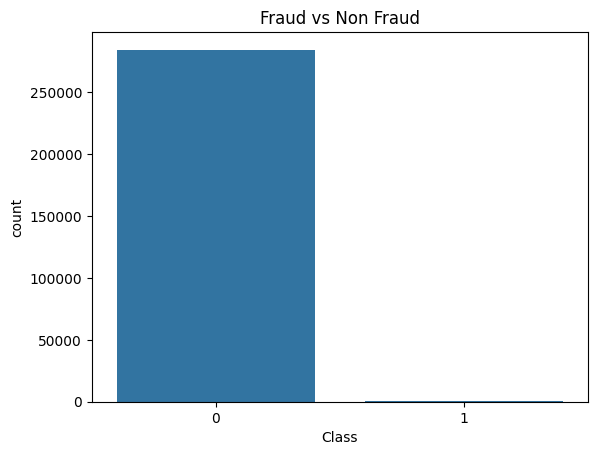

In [14]:
print("\nClass Distribution")
print(df["Class"].value_counts())

sns.countplot(x="Class", data=df)
plt.title("Fraud vs Non Fraud")
plt.show()

In [15]:
fraud_percentage = (
    df["Class"].value_counts(normalize=True)*100
)

print(fraud_percentage)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [17]:
df["Log_Amount"] = np.log1p(df["Amount"])

# Time in Hours

df["Hour"] = df["Time"] / 3600

In [18]:

df["Transaction_Category"] = pd.cut(
    df["Amount"],
    bins=[0,50,200,500,5000],
    labels=["Low","Medium","High","Very_High"]
)

print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V24       V25       V26       V27       V28  \
0  0.098698  0.363787  ...  0.066928  0.128539 -0.189115  0.133558 -0.021053   
1  0.085102 -0.255425  ... -0.339846  0.167170  0.125895 -0.008983  0.014724   
2  0.247676 -1.514654  ... -0.689281 -0.327642 -0.139097 -0.055353 -0.059752   
3  0.377436 -1.387024  ... -1.175575  0.647376 -0.221929  0.062723  0.061458   
4 -0.270533  0.817739  ...  0.141267 -0.206010  0.502292  0.219422  0.215153   

   Amount  Class  Log_Amount    

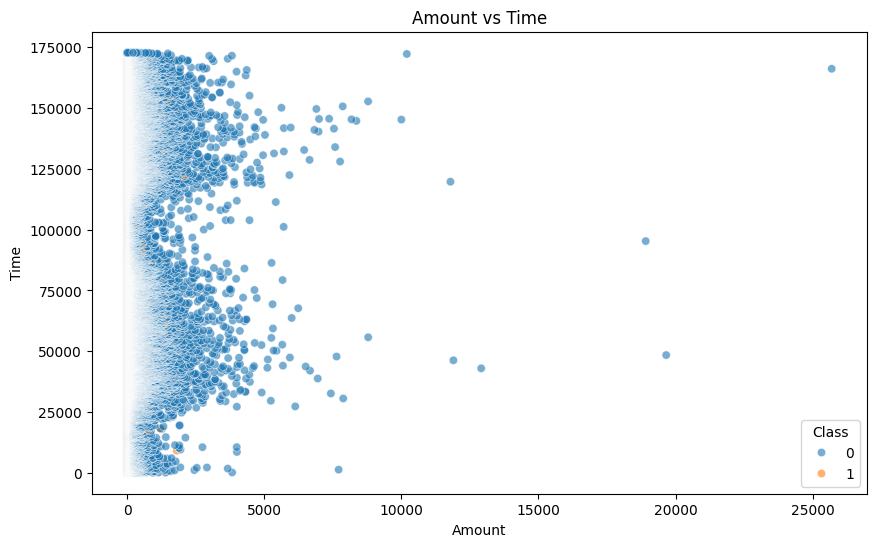

In [19]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Amount",
    y="Time",
    hue="Class",
    data=df,
    alpha=0.6
)

plt.title("Amount vs Time")
plt.show()

In [20]:
X = df.drop(
    ["Class","Transaction_Category"],
    axis=1
)

y = df["Class"]

In [21]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
etc = ExtraTreesClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

etc.fit(X_train, y_train)

y_pred = etc.predict(X_test)

In [25]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nExtra Trees Accuracy")
print(round(accuracy*100,2))


Extra Trees Accuracy
99.96


In [26]:
print("\nClassification Report")

print(
    classification_report(
        y_test,
        y_pred
    )
)


Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.95      0.82      0.88        98

    accuracy                           1.00     56962
   macro avg       0.98      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



In [28]:
prob = etc.predict_proba(X_test)[:,1]

auc = roc_auc_score(
    y_test,
    prob
)

print("\nROC AUC Score")
print(round(auc,4))


ROC AUC Score
0.9511



Top Features
V17     0.137601
V14     0.125121
V12     0.108991
V11     0.070307
V10     0.066447
V16     0.063142
V18     0.039140
V9      0.036589
V4      0.034761
V3      0.033729
V7      0.023179
V21     0.015116
V2      0.014922
V5      0.014281
Hour    0.014088
dtype: float64


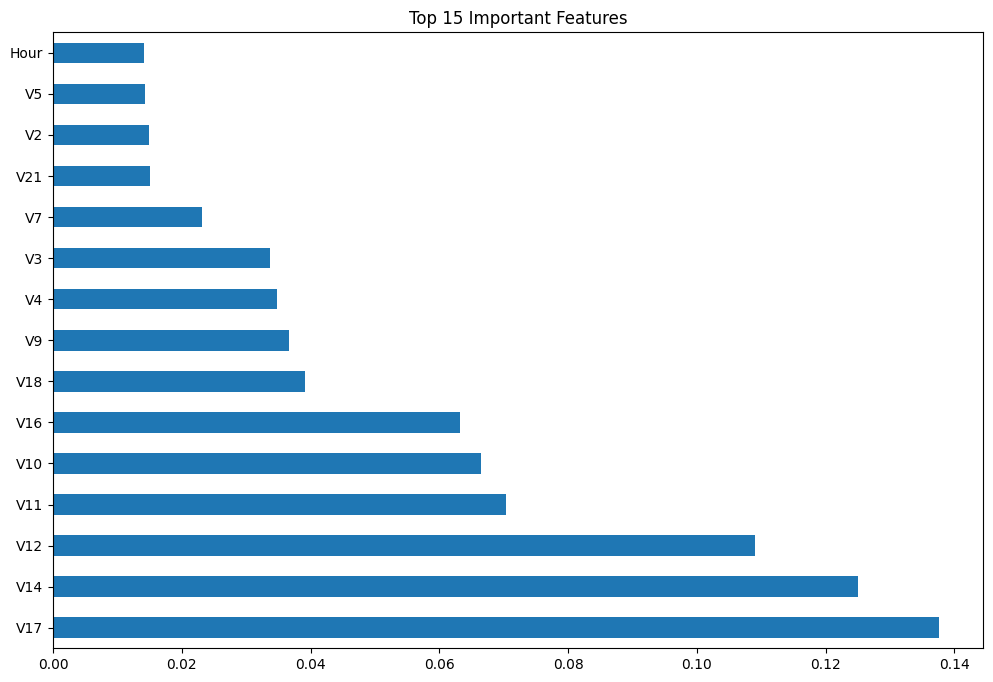

In [29]:

importance = pd.Series(
    etc.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(
    ascending=False
)

print("\nTop Features")
print(importance.head(15))

plt.figure(figsize=(12,8))

importance.head(15).plot(
    kind="barh"
)

plt.title("Top 15 Important Features")
plt.show()

In [30]:
iso = IsolationForest(
    contamination=0.002,
    random_state=42
)

iso.fit(X_scaled)

anomaly = iso.predict(X_scaled)

In [31]:
anomaly = np.where(
    anomaly == -1,
    1,
    0
)

In [32]:
iso_accuracy = accuracy_score(
    y,
    anomaly
)

print("\nIsolation Forest Accuracy")
print(round(iso_accuracy*100,2))


Isolation Forest Accuracy
99.72


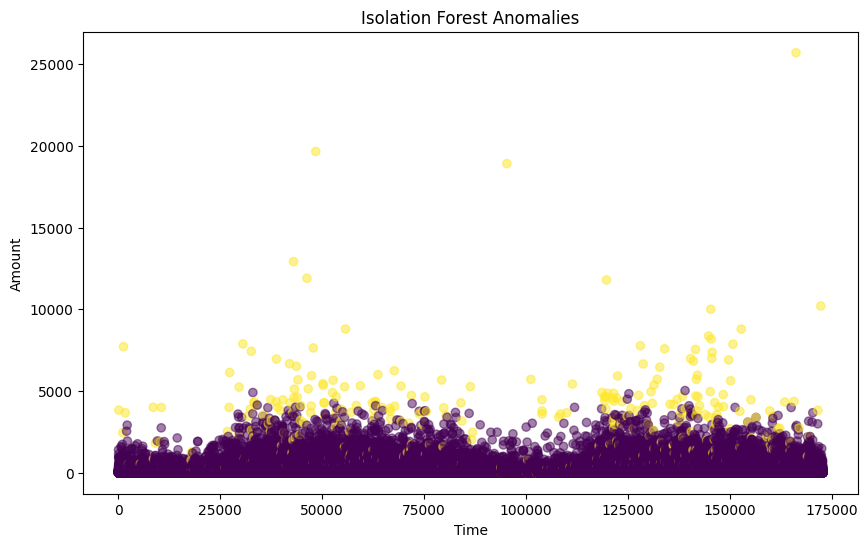

In [33]:

plt.figure(figsize=(10,6))

plt.scatter(
    df["Time"],
    df["Amount"],
    c=anomaly,
    alpha=0.5
)

plt.title("Isolation Forest Anomalies")
plt.xlabel("Time")
plt.ylabel("Amount")
plt.show()

In [34]:
sample = X_test[0:1]

prediction = etc.predict(sample)

if prediction[0] == 1:
    print("Fraud Transaction")
else:
    print("Normal Transaction")

Normal Transaction
